Attempt 2 Starting fresh please use prior for EDA info made second workbook due to so many lines it became confusing

In [30]:
### !pip install openpyxl

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # makes creating  plots easier.

# Load the dataset directly from a URL
import pandas as pd

df = pd.read_excel(r'C:\Users\lulul\OneDrive\Documents\School\2026\Machine Learning\Midterm Project\01 Call-Center-Dataset.xlsx')


print("--- First 5 Rows ---")
print(df.head())
print("--- Last 5 Rows ---")
print(df.tail())

--- First 5 Rows ---
  Call Id    Agent        Date      Time              Topic Answered (Y/N)  \
0  ID0001    Diane  2021-01-01  09:12:58   Contract related              Y   
1  ID0002    Becky  2021-01-01  09:12:58  Technical Support              Y   
2  ID0003  Stewart  2021-01-01  09:47:31   Contract related              Y   
3  ID0004     Greg  2021-01-01  09:47:31   Contract related              Y   
4  ID0005    Becky  2021-01-01  10:00:29    Payment related              Y   

  Resolved  Speed of answer in seconds AvgTalkDuration  Satisfaction rating  
0        Y                       109.0        00:02:23                  3.0  
1        N                        70.0        00:04:02                  3.0  
2        Y                        10.0        00:02:11                  3.0  
3        Y                        53.0        00:00:37                  2.0  
4        Y                        95.0        00:01:00                  3.0  
--- Last 5 Rows ---
     Call Id  Agent   

In [22]:
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())
print("--- Dataset Shape ---")
print(df.shape)
print("--- Dataset Info ---")
print(df.info)

--- Missing Values Before Cleaning ---
Call Id                         0
Agent                           0
Date                            0
Time                            0
Topic                           0
Answered (Y/N)                  0
Resolved                        0
Speed of answer in seconds    946
AvgTalkDuration               946
Satisfaction rating           946
dtype: int64
--- Dataset Shape ---
(5000, 10)
--- Dataset Info ---
<bound method DataFrame.info of      Call Id    Agent       Date      Time              Topic Answered (Y/N)  \
0     ID0001    Diane     Friday  09:12:58   Contract related              Y   
1     ID0002    Becky     Friday  09:12:58  Technical Support              Y   
2     ID0003  Stewart     Friday  09:47:31   Contract related              Y   
3     ID0004     Greg     Friday  09:47:31   Contract related              Y   
4     ID0005    Becky     Friday  10:00:29    Payment related              Y   
...      ...      ...        ...       ...

In [15]:
df.dtypes # Checking the data types of each column

Call Id                           str
Agent                             str
Date                              str
Time                           object
Topic                             str
Answered (Y/N)                    str
Resolved                          str
Speed of answer in seconds    float64
AvgTalkDuration                object
Satisfaction rating           float64
dtype: object

In [16]:
df.describe() # Getting summary statistics for the numerical columns in the dataset

,Speed of answer in seconds,Satisfaction rating
count,4054.000000,4054.000000
mean,67.520720,3.403552
std,33.592872,1.212220
min,10.000000,1.000000
25%,39.000000,3.000000
50%,68.000000,3.000000
75%,97.000000,4.000000
max,125.000000,5.000000


Checking null Data

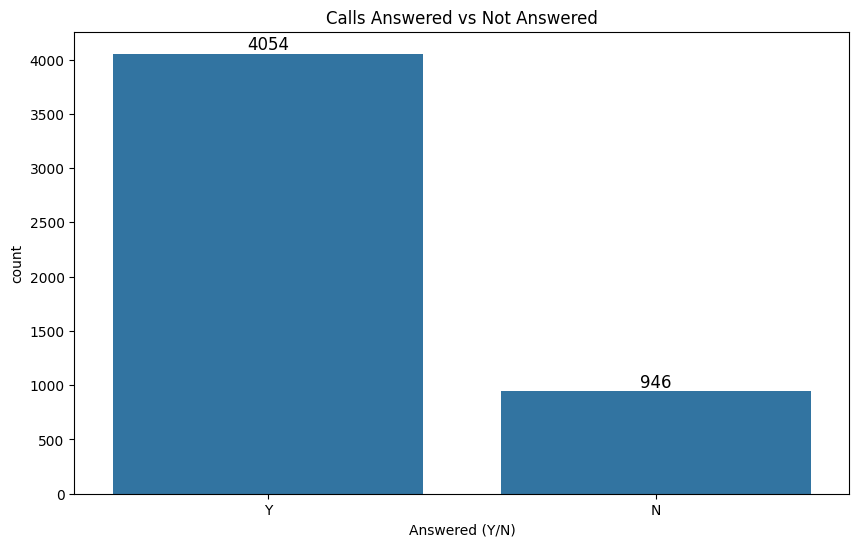

In [37]:
plt.figure(figsize=(10, 6))   # Set the figure size for better visibility
ax = sns.countplot(x='Answered (Y/N)', data=df)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),        # the count number
        (p.get_x() + p.get_width() / 2, p.get_height()),  # position
        ha='center', va='bottom',        # alignment
        fontsize=12
    )

plt.title('Calls Answered vs Not Answered')
plt.show()

In [18]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Resolved'].value_counts()

Resolved
Y    3646
N    1354
Name: count, dtype: int64

In [19]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['AvgTalkDuration'].value_counts()

AvgTalkDuration
00:04:43    22
00:02:11    21
00:05:43    19
00:06:15    18
00:02:44    18
            ..
00:06:27     4
00:04:34     4
00:02:28     4
00:05:38     3
00:00:30     3
Name: count, Length: 391, dtype: int64

New attempt at encoding Prior Notebook got overcomplicated 

Removed the not answered calls from the dataset since they have 0 talk duration and would skew the analysis. We want to focus on the calls that were actually answered to understand the factors that influence talk duration.

In [56]:
df_answered = df[df['Answered (Y/N)'] == 'Y'].copy()


Trying to clean and prep data

In [57]:
# 3. Clean 'AvgTalkDuration': Convert HH:MM:SS to total seconds
# We ensure it's a string, then convert to timedelta, then to total seconds
df_answered['AvgTalkDuration_sec'] = pd.to_timedelta(df_answered['AvgTalkDuration'].astype(str)).dt.total_seconds()

# Drop rows where Talk Duration couldn't be converted (NaNs)
df_answered = df_answered.dropna(subset=['AvgTalkDuration_sec'])

# 4. Feature Engineering: Get Day of the Week from the Date
df_answered['Date'] = pd.to_datetime(df_answered['Date'])
df_answered['DayOfWeek'] = df_answered['Date'].dt.day_name()

# 5. Prepare Data for Regression
# Select our independent variables (Features) and dependent variable (Target)
features = ['Agent', 'Topic', 'DayOfWeek']
target = 'AvgTalkDuration_sec'

In [58]:
encoded_df.head() #viewing the first 5 rows of the encoded dataset to confirm that the encoding process was successful and to see how the categorical variables have been transformed into numerical format.

,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating,Agent_Dan,Agent_Diane,Agent_Greg,Agent_Jim,Agent_Joe,Agent_Martha,Agent_Stewart,...,Date_Saturday,Date_Sunday,Date_Thursday,Date_Tuesday,Date_Wednesday,Topic_Contract related,Topic_Payment related,Topic_Streaming,Topic_Technical Support,Resolved_Y
0,109.0,143.0,3.0,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,70.0,242.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,10.0,131.0,3.0,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True
3,53.0,37.0,2.0,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
4,95.0,60.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


R-squared Score: -0.0015
Mean Squared Error: 13422.6272


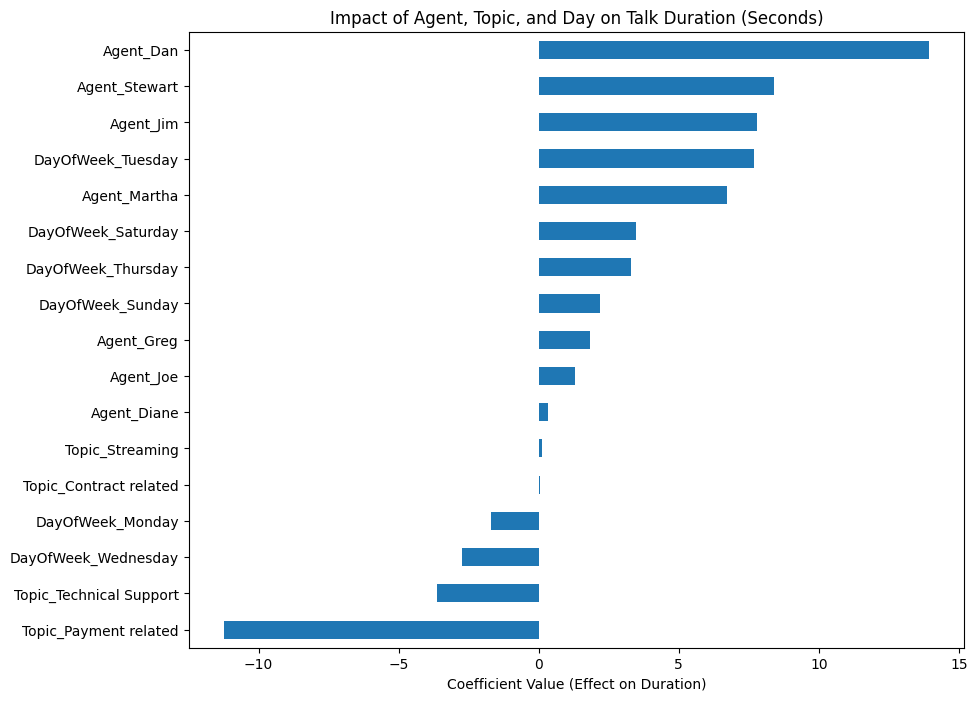

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



# Create Dummy Variables for categorical data (One-Hot Encoding)
X = pd.get_dummies(df_answered[features], drop_first=True)
y = df_answered[target]

# 6. Split and Train the Regression Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 7. Predictions and Evaluation
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

# 8. Visualizing Feature Importance (Coefficients)
importance = pd.Series(model.coef_, index=X.columns).sort_values()
plt.figure(figsize=(10, 8))
importance.plot(kind='barh')
plt.title('Impact of Agent, Topic, and Day on Talk Duration (Seconds)')
plt.xlabel('Coefficient Value (Effect on Duration)')
plt.show()

Maybe too much info removing agent

In [60]:
features = ['Topic', 'DayOfWeek']
target = 'AvgTalkDuration_sec'

R-squared Score: 0.0020
Mean Squared Error: 13374.7098


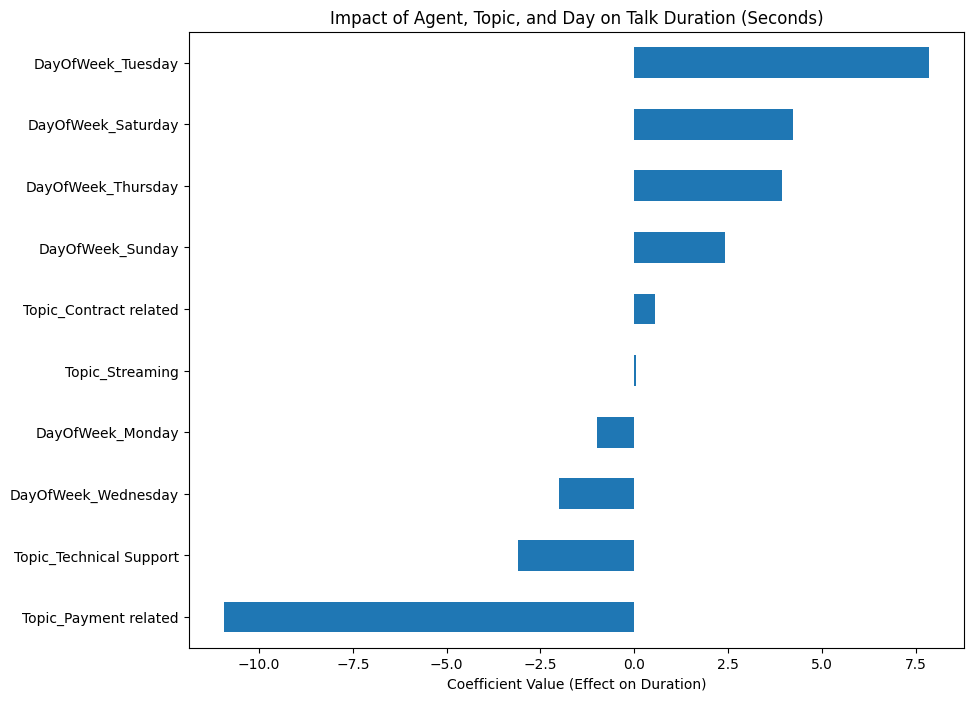

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



# Create Dummy Variables for categorical data (One-Hot Encoding)
X = pd.get_dummies(df_answered[features], drop_first=True)
y = df_answered[target]

# 6. Split and Train the Regression Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 7. Predictions and Evaluation
y_pred = model.predict(X_test)
print(f"R-squared Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.4f}")

# 8. Visualizing Feature Importance (Coefficients)
importance = pd.Series(model.coef_, index=X.columns).sort_values()
plt.figure(figsize=(10, 8))
importance.plot(kind='barh')
plt.title('Impact of Agent, Topic, and Day on Talk Duration (Seconds)')
plt.xlabel('Coefficient Value (Effect on Duration)')
plt.show()

Trying to use the median

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Use median as the target
y_median = encoded_df['AvgTalkDuration'].median()
print(f"Median AvgTalkDuration: {y_median:.2f} seconds")

# 2. Define features and target
X = pd.get_dummies(df_answered[features], drop_first=True)
y = df_answered[target]

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Compare predictions against median baseline
median_baseline = np.full_like(y_test, y_median)  # predicting median for everything

print(f"\n--- Your Model ---")
print(f"R² Score:  {r2_score(y_test, y_pred):.4f}")
print(f"MAE:       {mean_absolute_error(y_test, y_pred):.2f} seconds")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} seconds")

print(f"\n--- Median Baseline (just guessing median every time) ---")
print(f"MAE:       {mean_absolute_error(y_test, median_baseline):.2f} seconds")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, median_baseline)):.2f} seconds")

Median AvgTalkDuration: 226.00 seconds

--- Your Model ---
R² Score:  0.0020
MAE:       100.71 seconds
RMSE:      115.65 seconds

--- Median Baseline (just guessing median every time) ---
MAE:       100.82 seconds
RMSE:      115.77 seconds


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# 1. Use median as the target
y_mean = encoded_df['AvgTalkDuration'].mean()
print(f"Mean AvgTalkDuration: {y_mean:.2f} seconds")

# 2. Define features and target
X = pd.get_dummies(df_answered[features], drop_first=True)
y = df_answered[target]

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predict
y_pred = model.predict(X_test)

# 6. Compare predictions against median baseline
median_baseline = np.full_like(y_test, y_median)  # predicting median for everything

print(f"\n--- Your Model ---")
print(f"R² Score:  {r2_score(y_test, y_pred):.4f}")
print(f"MAE:       {mean_absolute_error(y_test, y_pred):.2f} seconds")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, y_pred)):.2f} seconds")

print(f"\n--- Median Baseline (just guessing median every time) ---")
print(f"MAE:       {mean_absolute_error(y_test, median_baseline):.2f} seconds")
print(f"RMSE:      {np.sqrt(mean_squared_error(y_test, median_baseline)):.2f} seconds")

Mean AvgTalkDuration: 224.92 seconds

--- Your Model ---
R² Score:  0.0020
MAE:       100.71 seconds
RMSE:      115.65 seconds

--- Median Baseline (just guessing median every time) ---
MAE:       100.82 seconds
RMSE:      115.77 seconds


Trying another regression model in this case logistic since liner is not yeilding progress.

In [69]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# Load the dataset
path = r'C:\Users\lulul\OneDrive\Documents\School\2026\Machine Learning\Midterm Project\01 Call-Center-Dataset.xlsx'
df = pd.read_excel(path)

# Convert 'AvgTalkDuration' to total seconds if it's in HH:MM:SS format
df['AvgTalkDuration_Sec'] = pd.to_timedelta(df['AvgTalkDuration'].astype(str)).dt.total_seconds()

# Check for missing values
df = df.dropna(subset=['AvgTalkDuration_Sec', 'Topic'])

In [ ]:
##continue to create a regression model to predict 'AvgTalkDuration_Sec' based on 'Topic' and other features as needed.

In [70]:
# Prepare the data
X = np.ones((len(df), 1))  # A constant column
y = df['AvgTalkDuration_Sec'].values

# Fit the model
model = LinearRegression(fit_intercept=False)
model.fit(X, y)

print(f"The mean AvgTalkDuration (via Regression Intercept) is: {model.coef_[0]:.2f} seconds")
print(f"Standard calculation mean: {df['AvgTalkDuration_Sec'].mean():.2f} seconds")

The mean AvgTalkDuration (via Regression Intercept) is: 224.92 seconds
Standard calculation mean: 224.92 seconds


In [71]:
# Convert Topics to dummy variables
X_topics = pd.get_dummies(df['Topic'], drop_first=True)
y = df['AvgTalkDuration_Sec']

# Fit the model
topic_model = LinearRegression()
topic_model.fit(X_topics, y)

# The intercept represents the mean duration of the 'dropped' first topic
print(f"Base Topic Mean Duration: {topic_model.intercept_:.2f} seconds")

Base Topic Mean Duration: 228.05 seconds


In [73]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Mean_Duration', y='Topic', data=X_topics_means, palette='magma')
plt.title('Average Talk Duration by Topic (Regression Means)')
plt.xlabel('Average Duration (Seconds)')
plt.ylabel('Topic')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print(topic_means)

NameError: name 'X_topics_means' is not defined

<Figure size 1000x600 with 0 Axes>

C:\Users\lulul\AppData\Local\Temp\ipykernel_28296\1701296464.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean_Duration', y='Topic', data=topic_means, palette='magma')


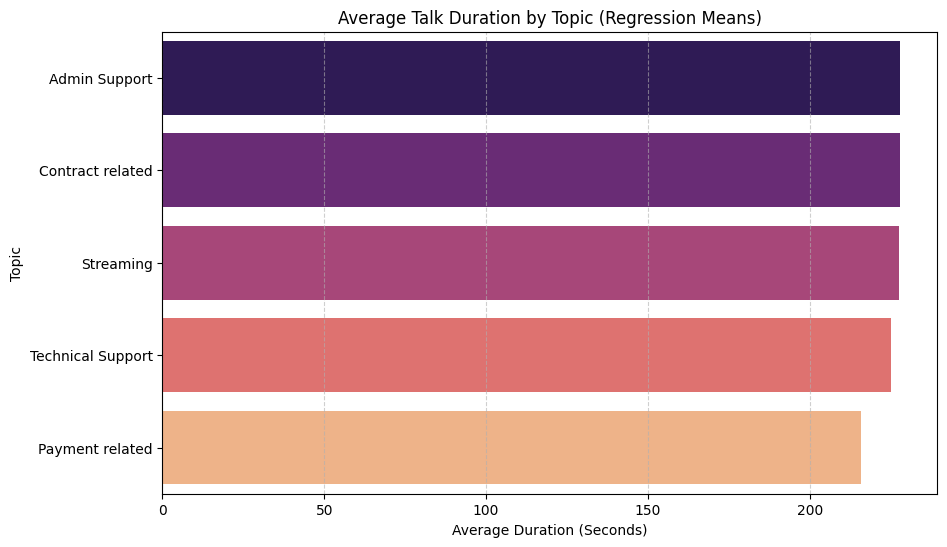

               Topic  Mean_Duration
0      Admin Support     228.047799
1   Contract related     228.012674
3          Streaming     227.730815
4  Technical Support     225.060870
2    Payment related     215.861858


In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Load your data
path = r'C:\Users\lulul\OneDrive\Documents\School\2026\Machine Learning\Midterm Project\01 Call-Center-Dataset.xlsx'
df = pd.read_excel(path)

# 2. Preprocessing: Convert HH:MM:SS to total seconds
def duration_to_seconds(time_str):
    if pd.isna(time_str): return 0
    # Handle cases where it might already be a datetime object or a string
    time_str = str(time_str)
    try:
        h, m, s = map(int, time_str.split(':'))
        return h * 3600 + m * 60 + s
    except:
        return 0

df['Duration_Sec'] = df['AvgTalkDuration'].apply(duration_to_seconds)

# 3. Filter for answered calls (as requested in your project goals)
df_answered = df[df['Answered (Y/N)'] == 'Y'].dropna(subset=['Topic', 'Duration_Sec'])

# 4. Regression to find the Mean per Topic
# This creates dummy variables for each topic
X = pd.get_dummies(df_answered['Topic'], drop_first=False)
y = df_answered['Duration_Sec']

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

# Store results in a DataFrame for plotting
topic_means = pd.DataFrame({
    'Topic': X.columns,
    'Mean_Duration': model.coef_
}).sort_values(by='Mean_Duration', ascending=False)

# 5. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Mean_Duration', y='Topic', data=topic_means, palette='magma')
plt.title('Average Talk Duration by Topic (Regression Means)')
plt.xlabel('Average Duration (Seconds)')
plt.ylabel('Topic')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print(topic_means)